# Mental Health in Technology-related Jobs

## 1. Importing the packages and loading the dataset
We usually start by importing the packages that we need (at least most of them) and loading the data in to a pandas dataframe


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('../data/mental-health-in-tech-2016_20161114.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1433, 63)


,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",...,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,0,26-100,1.0,NaN,Not eligible for coverage / N/A,NaN,No,No,I don't know,Very easy,...,Not applicable to me,Not applicable to me,39,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Sometimes
1,0,6-25,1.0,NaN,No,Yes,Yes,Yes,Yes,Somewhat easy,...,Rarely,Sometimes,29,male,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never
2,0,6-25,1.0,NaN,No,NaN,No,No,I don't know,Neither easy nor difficult,...,Not applicable to me,Not applicable to me,38,Male,United Kingdom,NaN,United Kingdom,NaN,Back-end Developer,Always
3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Sometimes,Sometimes,43,male,United Kingdom,NaN,United Kingdom,NaN,Supervisor/Team Lead,Sometimes
4,0,6-25,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,...,Sometimes,Sometimes,43,Female,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes


## 2. Exploring the stucture of the dataset
Next, we start exploring the dataset. Its best to identify the different column types, the number of non-null values and even calculate the percentage of missing values to identify the problematic columns.

In [2]:
print("<---------------Basic information about the dataset--------------->\n")
info = df.info()
print("\n<---------------End of Basic information--------------------->")

missing = df.isnull().mean() * 100
missing_df = missing.to_frame(name="percent_missing").sort_values("percent_missing", ascending=False)

print("\n\n<-----------Top 10 Columns with missing values------------>\n")
missing_df.head(10)

<---------------Basic information about the dataset--------------->

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   obje

,percent_missing
"If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?",89.951151
"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",85.764131
Is your primary role within your company related to tech/IT?,81.646895
Do you know local or online resources to seek help for a mental health disorder?,79.972087
Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,79.972087
Do you believe your productivity is ever affected by a mental health issue?,79.972087
"If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",79.972087
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?",79.972087
"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?",79.972087
"If maybe, what condition(s) do you believe you have?",77.529658


From the dataframe above, we can see that the survey has many categorical columns with missing values

## 3. Cleaning and preparing the data
To make the data suitable for clustering, we need to handle missing values, standardise certain text fields and convert ordinal categories to numeric representations. We need to :-
* Drop free-text columns that are difficult to encode
* Clean the 'gender' field by mapping various responses to 'Male', 'Female', 'Nonbinary' or 'Other'
* Map the employer size ranges and percentage ranges to numeric values
* Replace unrealistic ages (<10 or >100) with the median age
* Fill missing categorical values with 'unknown'

In [3]:
clean_df = df.copy()

# Dropping the free-text columns with long answers
cols_to_drop = [
    'Why or why not?',
    'Why or why not?.1',
    'If yes, what condition(s) have you been diagnosed with?',
    'If maybe, what condition(s) do you believe you have?',
    'If so, what condition(s) were you diagnosed with?'
]

for col in cols_to_drop:
    if col in clean_df.columns:
        clean_df = clean_df.drop(columns=col)
        
# Cleaning age by replacing unrealistic ages with median of reasonable ages
age_col = 'What is your age?'
if age_col in clean_df.columns:
    age_median = clean_df.loc[(clean_df[age_col] >= 10) & (clean_df[age_col] <= 100), age_col].median()
    clean_df.loc[(clean_df[age_col] < 10) | (clean_df[age_col] > 100), age_col] = np.nan
    clean_df[age_col] = clean_df[age_col].fillna(age_median)
    
# Cleaning the gender
def clean_gender(g):
    if pd.isna(g):
        return 'Unknown'
    g_str = str(g).strip().lower()
    male_terms = ['male', 'm', 'man', 'cis male', 'cis-male']
    female_terms = ['female', 'f', 'woman', 'cis female', 'cis-female']
    nb_terms = ['nonbinary', 'non-binary', 'genderqueer', 'gender fluid', 'nb', 'enby', 'agender', 'genderfluid']
    if any(term in g_str for term in male_terms):
        return 'Male'
    elif any(term in g_str for term in female_terms):
        return 'Female'
    elif any(term in g_str for term in nb_terms):
        return 'Nonbinary'
    else:
        return "Other"
    

if 'What is your gender?' in clean_df.columns:
    clean_df['gender_clean'] = clean_df['What is your gender?'].apply(clean_gender)
    clean_df = clean_df.drop(columns=['What is your gender?'])
    
# Mapping company size ranges to numeric values
size_mapping = {
    '1-5': 3,
    '6-25': 15.5,
    '26-100': 63,
    '100-500': 300,
    '500-1000': 750,
    'More than 1000': 1500
}

size_col = 'How many employees does your company or organization have?'
if size_col in clean_df.columns:
    clean_df['company_size_num'] = clean_df[size_col].map(size_mapping)
    # filling missing values with median
    clean_df['company_size_num'] = clean_df['company_size_num'].fillna(clean_df['company_size_num'].median())
    clean_df = clean_df.drop(columns=[size_col])
    
# Mapping percentage ranges to numeric midpoints
perc_mapping = {
    '0': 0,
    '1-25%': 13,
    '26-50%': 38,
    '51-75%': 63,
    '76-100%': 88,
    '100%': 100
}

perc_col = 'If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?'
if perc_col in clean_df.columns:
    clean_df['work_time_affected'] = clean_df[perc_col].map(perc_mapping)
    clean_df['work_time_affected'] = clean_df['work_time_affected'].fillna(0)
    clean_df = clean_df.drop(columns=[perc_col])
    
# Next we fill missing values for categorical columns but replacing blank strings with NaN and then fill with unknown
categorical_cols = clean_df.select_dtypes(include=['object']).columns
clean_df[categorical_cols] = clean_df[categorical_cols].replace('', np.nan)
clean_df[categorical_cols] = clean_df[categorical_cols].fillna('Unknown')

# Next we fill missing numeric columns with median values
numeric_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
clean_df[numeric_cols] = clean_df[numeric_cols].fillna(clean_df[numeric_cols].median())

print(f'Shape after cleaning = {clean_df.shape}')
clean_df.head()

Shape after cleaning = (1433, 58)


,Are you self-employed?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,...,What is your age?,What country do you live in?,What US state or territory do you live in?,What country do you work in?,What US state or territory do you work in?,Which of the following best describes your work position?,Do you work remotely?,gender_clean,company_size_num,work_time_affected
0,0,1.0,1.0,Not eligible for coverage / N/A,Unknown,No,No,I don't know,Very easy,No,...,39.0,United Kingdom,Unknown,United Kingdom,Unknown,Back-end Developer,Sometimes,Male,63.0,0.0
1,0,1.0,1.0,No,Yes,Yes,Yes,Yes,Somewhat easy,No,...,29.0,United States of America,Illinois,United States of America,Illinois,Back-end Developer|Front-end Developer,Never,Male,15.5,0.0
2,0,1.0,1.0,No,Unknown,No,No,I don't know,Neither easy nor difficult,Maybe,...,38.0,United Kingdom,Unknown,United Kingdom,Unknown,Back-end Developer,Always,Male,15.5,0.0
3,1,1.0,1.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,...,43.0,United Kingdom,Unknown,United Kingdom,Unknown,Supervisor/Team Lead,Sometimes,Male,300.0,13.0
4,0,0.0,1.0,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,...,43.0,United States of America,Illinois,United States of America,Illinois,Executive Leadership|Supervisor/Team Lead|Dev ...,Sometimes,Male,15.5,0.0


## 4. Encode categorical variables and scale numeric features
Now that we are done with cleaning, we need to convert the categorical variables in to numeric features and scale all variables. We can use pd.get_dummies() for one hot encoding and sckit learn's StandardScaler to standardise numeric columns

In [4]:
# We start off by identifying numeric and categorical features
numeric_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = clean_df.select_dtypes(include=['object']).columns

# Next, we one hot encode categorical variables
X_cat = pd.get_dummies(clean_df[categorical_cols], drop_first=False)

# Next we combine numerical and encoded categorical data
X_numeric = clean_df[numeric_cols].reset_index(drop=True)
X_processed = pd.concat([X_numeric, X_cat], axis=1)

# Now we standardise the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_processed)

print(f'Shape of the processed data is (rows, features): {X_scaled.shape}')

Shape of the processed data is (rows, features): (1433, 668)


## 5. Determine the number of clusters
To decide how many clusters to use for k means, we need to compute the silhouette scores for a range of values of k

    k  silhouette_score
0   2          0.149101
1   3          0.003965
2   4          0.010111
3   5          0.012635
4   6         -0.002311
5   7         -0.025457
6   8          0.004027
7   9         -0.003685
8  10          0.002850


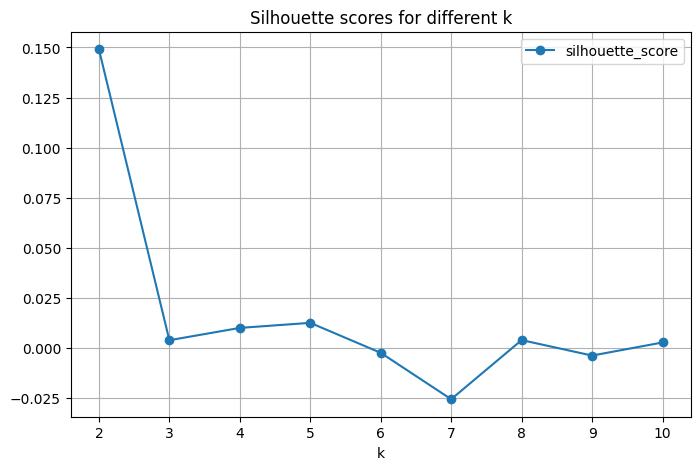

In [5]:
range_n_clusters = range(2,11)
silhouette_scores = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels= kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    
# Creating a dataframe of results:
silhouette_df = pd.DataFrame({
    'k': list(range_n_clusters),
    'silhouette_score': silhouette_scores
})

print(silhouette_df)


silhouette_df.plot(x='k', y='silhouette_score', kind='line', marker='o', figsize=(8,5))
plt.title('Silhouette scores for different k')
plt.grid(True)
plt.show()

Based on the graph above we can set the final value of k as 2. Although the score is low overall, k > 2 results in worse silhouette scores.

In [6]:
final_k = 2
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Adding cluster labels back to the cleaned dataframe
clean_df['cluster'] = cluster_labels

# Showing the size of each cluster
cluster_counts = clean_df['cluster'].value_counts().sort_index()
print(cluster_counts)

cluster
0    1146
1     287
Name: count, dtype: int64


## 6. Dimensionality reduction and Visualisation
In order to visualise the clusters in two dimensions, we are going to use Principal Component Analysis (PCA). We would project the scaled feature matrix on to the first two principal components and plot each participant coloured by their clustered label

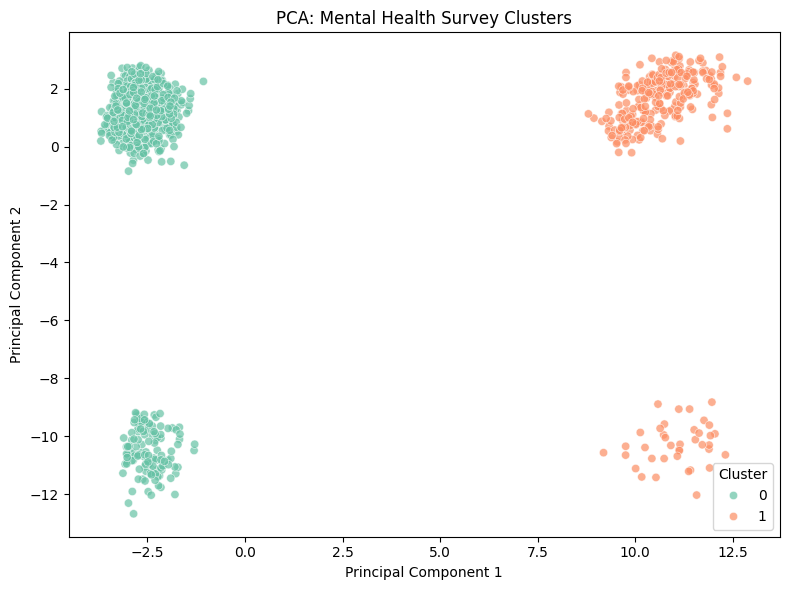

In [7]:
# Applying PCA to reduce to two components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Create a dataframe for plotting
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'cluster': cluster_labels
})

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='Set2', alpha=0.7)
plt.title('PCA: Mental Health Survey Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.tight_layout()

## 7. Cluster characterization
Finally, we examine the characteristics of each cluster to understand how they differ. We compute summary statistics numeric variable like age and company size and also look at the distribution of selected categorical variables

In [8]:
# Summary statistics for numeric variables by cluster
numeric_summary = clean_df.groupby('cluster')[['What is your age?', 'company_size_num', 'work_time_affected']].mean()

# Distribution of selected categorical variables
categorical_vars = [
    'Are you self-employed', 
    'gender_clean',
    'Do you currently have a mental health disorder?',
    'Do you have a family history of mental illness?'
]

categorical_summary = {}
for var in categorical_vars:
    if var in clean_df.columns:
        counts = clean_df.groupby('cluster')[var].value_counts(normalize=True).unstack().fillna(0)
        categorical_summary[var] = counts
        
print('Numeric Summary:')
print(numeric_summary)

for var, table in categorical_summary.items():
    print(f"Distribution of '{var}' by cluster (proportion):")
    print(table)

Numeric Summary:
         What is your age?  company_size_num  work_time_affected
cluster                                                         
0                33.428447        471.405759            0.000000
1                36.804878        300.000000           23.700348
Distribution of 'gender_clean' by cluster (proportion):
gender_clean    Female      Male  Nonbinary     Other   Unknown
cluster                                                        
0             0.040140  0.943281   0.008726  0.005236  0.002618
1             0.066202  0.926829   0.003484  0.003484  0.000000
Distribution of 'Do you currently have a mental health disorder?' by cluster (proportion):
Do you currently have a mental health disorder?     Maybe        No       Yes
cluster                                                                      
0                                                0.221640  0.384817  0.393543
1                                                0.254355  0.313589  0.432056
Distribu

## 8. Conclusion
We have now cleaned and prepared a complex survey dataset, encoded its variables, reduced its dimensionality and applied unsupervised clustering to identify similar groups of participants. The PCA plot above shows a two-dimensional representation of the clusters where the summary statistics reveal how the clusters differ in terms of age, company size and mental health history